Script
- Performs dimesionality reduction using PCA on binned and filtered data.
- Highly Variable Genes
- Leiden clusters
- Projects the clusters using UMAP.
- Finds highly expressed genes in each cluster
- Writes and exports highly expressed genes in each cluster to a dataframe.

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import anndata as ad
import seaborn as sns
from datetime import datetime
import time, gc, warnings, pickle, os, re
from PIL import Image, ImageColor
import random, matplotlib
from scipy.sparse import csr_matrix, hstack, coo_matrix
from scipy.stats import gaussian_kde
# from KDEpy import FFTKDE
from scipy.signal import convolve2d
from scipy.sparse import vstack
from scipy import signal
import ipyparallel as ipp
from matplotlib.colors import ListedColormap
from PIL import ImageColor
from matplotlib.ticker import AutoMinorLocator
import matplotlib.cm as cm

In [2]:
def plot_gene_conv(gene_name, adata, s=3, vmax_adjust=0.5, core_size=50, std=25, mask=np.ones((5000,5000))): 
    plt.figure(figsize = (16,16))
    gene_idx = adata.var.reset_index().query('gene_name == @gene_name').index
    gene_data = (adata.X[:,gene_idx].reshape(5000,5000).toarray())*mask
    kernel = np.outer(signal.windows.gaussian(core_size, std),
                  signal.windows.gaussian(core_size, std))
    gmatrix = signal.fftconvolve(gene_data, kernel, mode='same')
    gene_data = coo_matrix(gene_data)
    x_u, y_u = gene_data.row.reshape(-1,1), gene_data.col.reshape(-1,1)
    z = gmatrix[x_u,y_u]
    plt.figure(figsize=(12,12))
    plt.scatter(y_u, x_u, c=z, marker='h', s=s, edgecolor='none',
                       cmap='magma_r', vmin=0, vmax=vmax_adjust*max(z))
    plt.xlim(-250, 5350)
    plt.ylim(-250, 5350)
    plt.gca().set_aspect('equal')
    plt.title('%s mapped zipcode positions' % gene_name)
    plt.xlabel('zipcode index')
    plt.ylabel('zipcode index')
    plt.grid(False)
    print('plotted %s' % gene_name)

In [ ]:
adata_bin = sc.read_h5ad("/path/to/file/binned_filtered_5_features.h5ad")

In [4]:
adata_bin

AnnData object with n_obs × n_vars = 429022 × 17668
    obs: 'array_col', 'array_row', 'ngenes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes'
    var: 'gene_ids', 'total_counts', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'n_cells'
    uns: 'bin_size', 'conv_size', 'l', 'l2', 'l3', 'log1p'

In [5]:
# PCA analysis
sc.tl.pca(adata_bin, svd_solver = 'arpack')

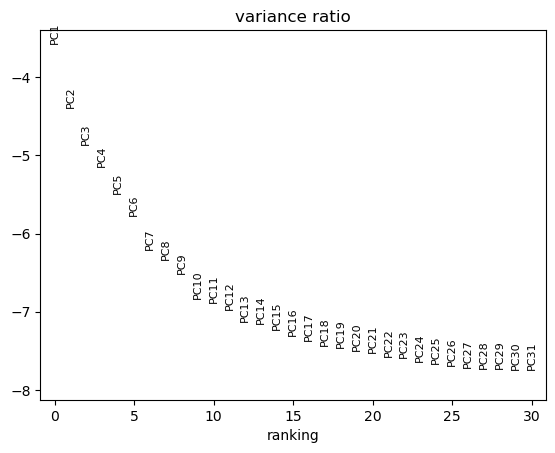

In [6]:
sc.pl.pca_variance_ratio(adata_bin, log = True)

In [7]:
# before filtering get a copy of binned data because filtering is an irreversible step.
adata_raw = adata_bin

In [8]:
adata_bin

AnnData object with n_obs × n_vars = 429022 × 17668
    obs: 'array_col', 'array_row', 'ngenes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes'
    var: 'gene_ids', 'total_counts', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'n_cells'
    uns: 'bin_size', 'conv_size', 'l', 'l2', 'l3', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [9]:
# parameters for PCA and clustering
top_genes = 3000
n_comps = 25
random_state = 4
flavor = 'seurat_v3'

In [10]:
sc.pp.highly_variable_genes(adata_bin, flavor=flavor, n_top_genes=top_genes)

/home/jselab/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [11]:
adata_bin = adata_bin[:, adata_bin.var.highly_variable]

In [12]:
"MYB" in adata_bin.var.highly_variable

True

In [13]:
sc.pp.pca(adata_bin, n_comps=n_comps, random_state=random_state)
sc.pp.neighbors(adata_bin)

/home/jselab/miniconda3/envs/spatial/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:317: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


In [14]:
sc.tl.umap(adata_bin)

In [15]:
sc.tl.leiden(adata_bin, key_added="leiden", resolution=0.25)

/tmp/ipykernel_458840/1797151209.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_bin, key_added="leiden", resolution=0.25)


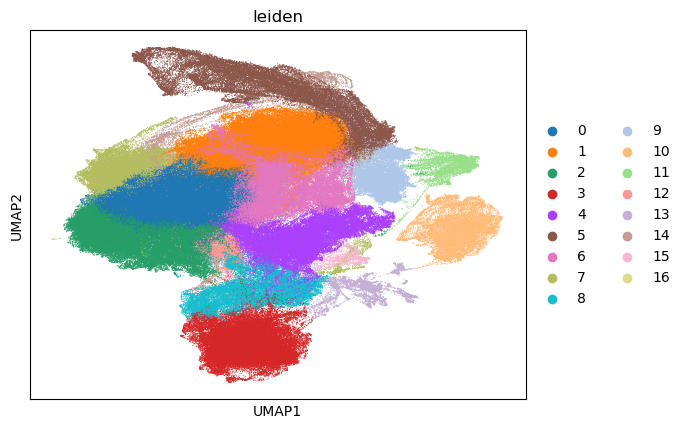

In [16]:
sc.pl.umap(adata_bin, color = ['leiden'], size=2, color_map='tab20')

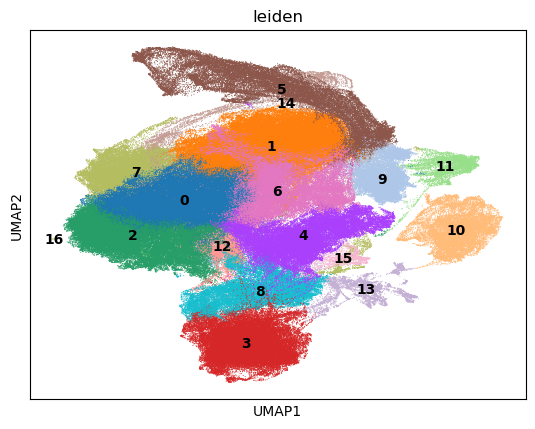

In [17]:
sc.pl.umap(adata_bin, color = ['leiden'], size=2, color_map='tab20', legend_loc='on data')

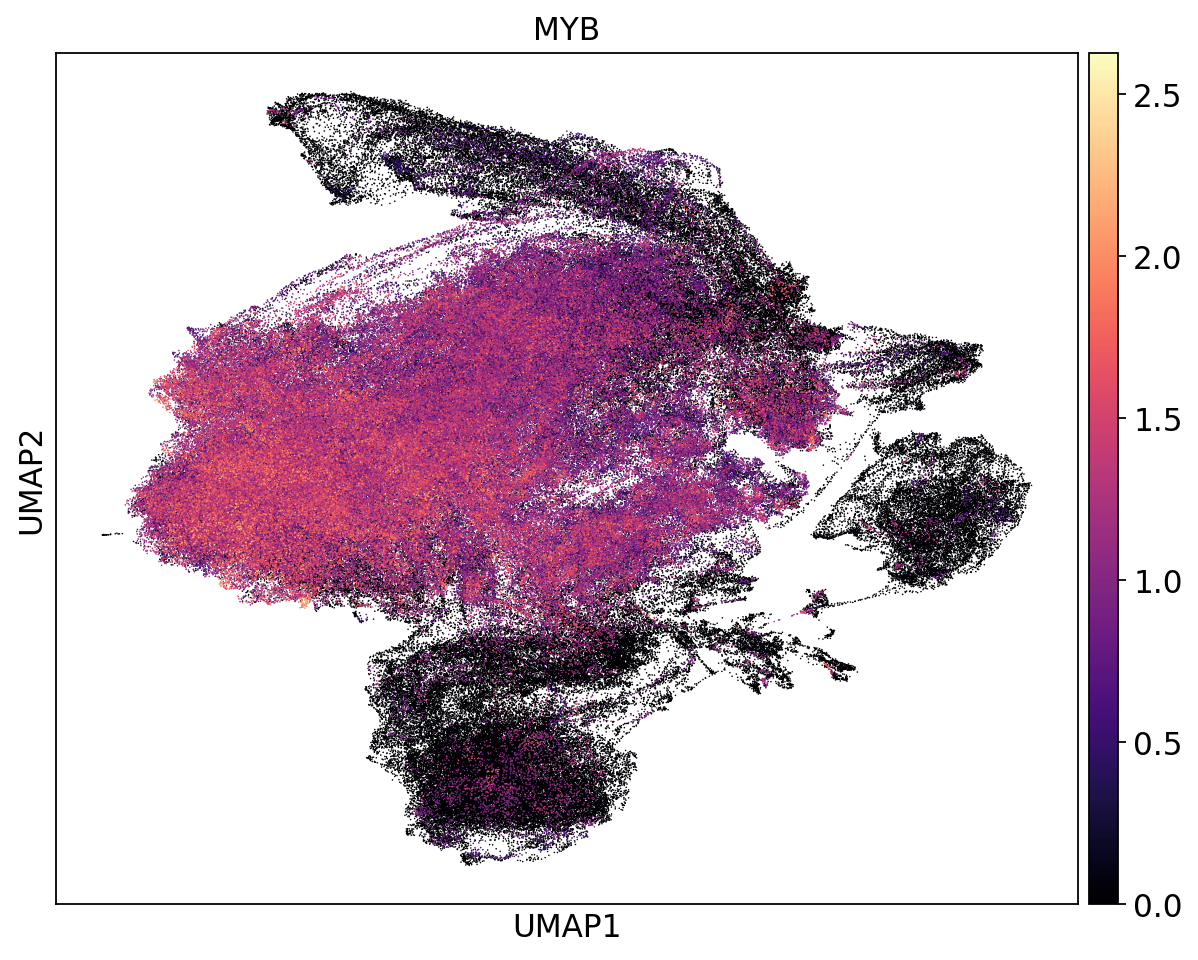

In [18]:
sc.set_figure_params(figsize = (9, 7))
sc.pl.umap(adata_bin, color = ['MYB'], size = 2, color_map='magma')

In [ ]:
adata_bin.write_h5ad("/path/to/file/clustered_seurat_v3_myb_0_cluster.h5ad")

In [31]:
# sc.tl.rank_genes_groups(adata_bin, 'leiden', method = 'wilcoxon')
# sc.pl.rank_genes_groups(adata_bin, n_genes = 25, sharey = False)

Getting the csv dataset of marker genes.

In [32]:
# df = sc.get.rank_genes_groups_df(adata_bin, None)